### Imports

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

### Data

In [123]:
# Dane pomiarowe

lam_turb_data = {
    "p_1": [
        # Iteration 1 laminar
        217, 224, 229, 233, 240, 256, 281,
        # Iteration 1 turbulent
        None, None, None, None, None, None, None,

        # Iteration 2 laminar
        19.5, 20.6, 21.5, 22.3, 23.5, 26.7, 28.5,
        # Iteration 2 turbulent
        None, None, None, None, None, None, None,

        # Iteration 3 laminar
        212, 221, 233, 259, 269, 295, 342,
        # Iteration 3 turbulent
        None, None, None, None, None, None, None,

        # Iteration 4 laminar
        20.8, 21.8, 23.3, 24.7, 26.4, 27.7, 29.4,
        # Iteration 4 turbulent
        None, None, None, None, None, None, None,

        # Iteration 5 laminar
        21.8, 22.5, 23.3, 24.1, 25.3, 26.0, 27.4,
        # Iteration 5 turbulent
        None, None, None, None, None, None, None,

        # Iteration 6 laminar
        21.8, 23.8, 24.8, 25.8, 26.3, 24.3, 28.0,
        # Iteration 6 turbulent
        None, None, None, None, None, None, None,

        # Iteration 7 laminar
        220, 230, 240, 250, 261, 271, 281,
        # Iteration 7 turbulent
        None, None, None, None, None, None,

        # Iteration 8 laminar (9 rows)
        19.5, 20.0, 20.5, 21.5, 22.5, 24.0, 26.1, 28.5, 31.4,
        # Iteration 8 turbulent
        None, None, None, None, None, None, None,

        # Iteration 9 laminar
        21.8, 22.5, 23.3, 24.1, 25.3, 26.0, 27.4,
        # Iteration 9 turbulent
        None, None, None, None, None, None, None,

        # Iteration 10 laminar
        21.8, 22.5, 23.3, 24.1, 25.3, 26.0, 27.4,
        # Iteration 10 turbulent
        None, None, None, None, None, None, None
    ],

    "p_2": [
        # Iteration 1 laminar
        193, 194, 185, 180, 170, 151, 122,
        None, None, None, None, None, None, None,

        # Iteration 2 laminar
        18.1, 17.1, 16.0, 15.0, 13.5, 9.5, 7.2,
        None, None, None, None, None, None, None,

        # Iteration 3 laminar
        191, 180, 170, 138, 125, 94, 37,
        None, None, None, None, None, None, None,

        # Iteration 4 laminar
        18.7, 17.3, 15.6, 13.8, 12.9, 10.4, 8.3,
        None, None, None, None, None, None, None,

        # Iteration 5 laminar
        20.1, 19.4, 18.5, 17.5, 16.0, 15.0, 13.6,
        None, None, None, None, None, None, None,

        # Iteration 6 laminar
        19.5, 17.5, 16.5, 15.5, 14.4, 13.4, 12.4,
        None, None, None, None, None, None, None,

        # Iteration 7 laminar
        198, 183, 169, 157, 143, 132, 120,
        None, None, None, None, None, None,

        # Iteration 8 laminar
        17.5, 10.8, 16.2, 15.0, 13.5, 11.5, 9.3, 6.3, 2.8,
        None, None, None, None, None, None, None,

        # Iteration 9 laminar
        20.1, 19.4, 18.5, 17.5, 16.0, 15.0, 13.6,
        None, None, None, None, None, None, None,

        # Iteration 10 laminar
        20.1, 19.4, 18.5, 17.5, 16.0, 15.0, 13.6,
        None, None, None, None, None, None, None
    ],

    "p_diff": [
        # Iteration 1 laminar
        None, None, None, None, None, None, None,
        # Iteration 1 turbulent
        0.05, 0.10, 0.12, 0.14, 0.16, 0.075, 0.18,

        # Iteration 2 laminar
        None, None, None, None, None, None, None,
        # Iteration 2 turbulent
        0.05, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20,

        # Iteration 3 laminar
        None, None, None, None, None, None, None,
        # Iteration 3 turbulent
        0.05, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20,

        # Iteration 4 laminar
        None, None, None, None, None, None, None,
        # Iteration 4 turbulent
        0.05, 0.075, 0.10, 0.12, 0.14, 0.16, 0.18,

        # Iteration 5 laminar
        None, None, None, None, None, None, None,
        # Iteration 5 turbulent
        0.05, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20,

        # Iteration 6 laminar
        None, None, None, None, None, None, None,
        # Iteration 6 turbulent
        0.050, 0.10, 0.120, 0.140, 0.110, 0.180, 0.075,

        # Iteration 7 laminar
        None, None, None, None, None, None, None,
        # Iteration 7 turbulent
        0.05, 0.075, 0.10, 0.12, 0.14, 0.16,

        # Iteration 8 laminar
        None, None, None, None, None, None, None, None, None,
        # Iteration 8 turbulent
        0.05, 0.075, 0.10, 0.12, 0.14, 0.16, 0.18,

        # Iteration 9 laminar
        None, None, None, None, None, None, None,
        # Iteration 9 turbulent
        0.05, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20,

        # Iteration 10 laminar
        None, None, None, None, None, None, None,
        # Iteration 10 turbulent
        0.05, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20
    ],

    "time": [
        # Iteration 1 laminar
        363.79, 285.92, 206.25, 185.40, 146.44, 108.40, 92.59,
        201.96, 124.12, 94.90, 87.75, 84.87, 130.61, 78.60,

        # Iteration 2 laminar
        600.1, 212.4, 151.2, 132.0, 90.6, 77.4, 73.2,
        142.2, 125.4, 90.0, 87.0, 81.6, 78.0, 75.0,

        # Iteration 3 laminar
        444.56, 222.50, 157.87, 101.43, 95.56, 84.31, 66.34,
        155.40, 125.72, 125.19, 104.47, 95.16, 90.88, 87.22,

        # Iteration 4 laminar
        404, 195, 132, 107, 102, 89, 80,
        172, 137, 119, 109, 101, 90, 87,

        # Iteration 5 laminar
        443.88, 277.88, 191.34, 145.57, 118.03, 108.78, 98.79,
        172.75, 125.93, 115.56, 101.28, 91.88, 88.03, 80.16,

        # Iteration 6 laminar
        375.53, 153.13, 122.34, 108.50, 98.40, 93.00, 89.66,
        165.43, 114.28, 104.21, 95.25, 84.18, 78.75, 128.35,

        # Iteration 7 laminar
        324.91, 183.25, 135.66, 111.25, 98.03, 93.03, 88.50,
        136.66, 112.12, 102.00, 94.66, 87.41, 83.41,

        # Iteration 8 laminar
        7.49, 4.37, 3.40, 2.36, 2.06, 1.41, 1.30, 1.19, 1.09,
        2.41, 2.25, 2.00, 1.48, 1.40, 1.35, 1.26,

        # Iteration 9 laminar
        443.88, 277.88, 191.34, 145.57, 118.03, 108.78, 98.79,
        172.75, 125.93, 115.56, 101.28, 91.88, 88.03, 80.16,

        # Iteration 10 laminar
        443.88, 277.88, 191.34, 145.57, 118.03, 108.78, 98.79,
        172.75, 125.93, 115.56, 101.28, 91.88, 88.03, 80.16
    ],

    "volume": [
        # laminar always 0.5
        *([0.5] * 72),
        # turbulent always 2
        *([2] * 69)
    ],

    "regime": [
        *(["laminar"] * 72),
        *(["turbulent"] * 69)
    ]
}


data = {
    "p_1": [22.3, 22.7, 23.4, 24.6, 25.0, 25.5, 26.1, 26.5,
                27.0, 27.6, 28.0, 28.5, 21.4, 21.8, 22.4, 22.8],
    "p_2":    [18.9, 18.4, 17.4, 15.8, 15.4, 14.8, 14.0, 13.5,
                13.1, 12.0, 11.8, 11.2, 19.9, 19.4, 18.8, 18.3],
    "p_diff": [3.4, 4.3, 6.0, 8.8, 9.6, 10.7, 12.1, 13.0,
                13.9, 15.6, 16.2, 17.3, 1.5, 2.4, 3.6, 4.5],
    "Q": [2.1413e-06, 2.5917e-06, 3.2342e-06, 4.2427e-06, 4.7596e-06, 4.8567e-06,
          5.0416e-06, 5.1282e-06, 5.9471e-06, 5.7637e-06, 6.0350e-06, 6.2598e-06,
          1.1109e-06, 1.5067e-06, 2.0272e-06, 2.7439e-06],
}

### Computation

In [124]:

# Przeliczanie danych z Teamsa (dane do digitalizacji)

PI = 3.14
D = 0.003
nu = 1e-6

df_1 = pd.DataFrame(lam_turb_data)

df_1["P_1_Pa"] = df_1["p_1"].astype(float) * 9.81
df_1["P_2_Pa"] = df_1["p_2"].astype(float) * 9.81

df_1["P_diff_bar_Pa"] = df_1["p_diff"].astype(float) * 1e5

df_1["P_diff_Pa"] = np.where(
    df_1["p_1"].notna() & df_1["p_2"].notna(),
    (df_1["P_1_Pa"] - df_1["P_2_Pa"]),
    df_1["P_diff_bar_Pa"]      
)

df_1["volume_m3"] = df_1["volume"] / 1000
df_1["Q_m3s"] = df_1["volume_m3"] / df_1["time"]
df_1["Re"] = 4 * df_1["Q_m3s"] / (PI * D * nu)

# Kryterium:
#   Re < 2000             -> laminarny
#   2000 <= Re < 3000      -> przejściowy
#   Re >= 3000             -> turbulentny
#
# Mapowanie liczbowe:
#   0 -> laminar (laminarny)
#   1 -> transitional (przejściowy)
#   2 -> turbulent (turbulentny)

conditions = [
    df_1["Re"] < 2000,
    (df_1["Re"] >= 2000) & (df_1["Re"] < 3000),
    df_1["Re"] >= 3000
]

choices = ["laminar", "transitional", "turbulent"]

df_1["Regime"] = np.select(
    conditions,
    choices,
    default="unknown"
)

# --- final column order ---
df_1 = df_1[[
    "P_1_Pa", "P_2_Pa", "P_diff_Pa",
    "Q_m3s", "Re", "Regime"
]]

In [125]:
# Przeliczanie danych pomiarowych

df_2 = pd.DataFrame(data)

# Obliczenie liczby Reynoldsa (Re)

D = 0.003     # średnica przewodu [m]
nu = 1e-6     # lepkość kinematyczna wody [m2/s]

# --- convert p1 and p2 to Pascals (mmH2O → Pa) ---
df_2["P_1_Pa"] = df_2["p_1"].astype(float) * 9.81
df_2["P_2_Pa"] = df_2["p_2"].astype(float) * 9.81
df_2["P_diff_Pa"] = df_2["P_1_Pa"] - df_2["P_2_Pa"]

df_2["Q_m3s"] = df_2["Q"]
df_2.drop(columns=["Q"], inplace=True)
df_2["Re"] = 4 * df_2["Q_m3s"] / (np.pi * D * nu)


# Kryterium:
#   Re < 2000             -> laminarny
#   2000 <= Re < 3000      -> przejściowy
#   Re >= 3000             -> turbulentny
#
# Mapowanie liczbowe:
#   0 -> laminar (laminarny)
#   1 -> transitional (przejściowy)
#   2 -> turbulent (turbulentny)

conditions = [
    df_2["Re"] < 2000,
    (df_2["Re"] >= 2000) & (df_2["Re"] < 3000),
    df_2["Re"] >= 3000,
]
choices = ["laminar", "transitional", "turbulent"]
df_2["Regime"] = np.select(conditions, choices, default="turbulent")

df_2 = df_2[[
    "P_1_Pa", "P_2_Pa", "P_diff_Pa",
    "Q_m3s", "Re", "Regime"
]]

df = pd.concat([df_1, df_2], ignore_index=True)
df


,P_1_Pa,P_2_Pa,P_diff_Pa,Q_m3s,Re,Regime
0,2128.770,1893.330,235.440,0.000001,583.617540,laminar
1,2197.440,1903.140,294.300,0.000002,742.565141,laminar
2,2246.490,1814.850,431.640,0.000002,1029.402303,laminar
3,2285.730,1765.800,519.930,0.000003,1145.168420,laminar
4,2354.400,1667.700,686.700,0.000003,1449.837647,laminar
...,...,...,...,...,...,...
152,279.585,109.872,169.713,0.000006,2656.741634,transitional
153,209.934,195.219,14.715,0.000001,471.480603,laminar
154,213.858,190.314,23.544,0.000002,639.463341,laminar
155,219.744,184.428,35.316,0.000002,860.370402,laminar


### Model

In [126]:
# Klasyfikacja RandomForest
# x - ciśnienia przed i za
# y - laminar/turbulent/transitional

X = df[["P_diff_Pa", "Q_m3s"]].values
y = df["Regime"].values              

print(f"Wymiary X (cechy):   {X.shape}")
print(f"Wymiary y (etykiety): {y.shape}")
print()

# Podzial danych na zbiór treningowy i testowy (80%/20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% danych do testu
    random_state=42,     # ustalony seed
)

print(f"Liczba próbek treningowych: {len(X_train)}")
print(f"Liczba próbek testowych:    {len(X_test)}")
print()


# Las losowy - odpowiednik TreeBagger w MATLAB-ie

rf_model = RandomForestClassifier(
    n_estimators=300,
    bootstrap=True,
    min_samples_leaf=1,
    max_leaf_nodes=10,
    max_samples=0.8,
    oob_score=True,
    random_state=42,
)

rf_model.fit(X_train, y_train)

print(f"Wynik OOB (Out-Of-Bag) na zbiorze treningowym: {rf_model.oob_score_:.4f}")
print(f"Klasy rozpoznane przez model: {list(rf_model.classes_)}")
print()


# Predykcja i ocena dokładności

predicted_labels = rf_model.predict(X_test)
scores = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, predicted_labels)

print("Porównanie predykcji z rzeczywistymi etykietami (zbiór testowy):")
for true_label, pred_label in zip(y_test, predicted_labels):
    znacznik = "OK" if true_label == pred_label else "BŁĄD"
    print(f"  rzeczywisty: {true_label:<13}  przewidziany: {pred_label:<13}  [{znacznik}]")
print()
print(f"Dokładność (Accuracy): {accuracy * 100:.2f}%")
print()

Wymiary X (cechy):   (157, 2)
Wymiary y (etykiety): (157,)

Liczba próbek treningowych: 125
Liczba próbek testowych:    32

Wynik OOB (Out-Of-Bag) na zbiorze treningowym: 0.9840
Klasy rozpoznane przez model: ['laminar', 'transitional', 'turbulent']

Porównanie predykcji z rzeczywistymi etykietami (zbiór testowy):
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: laminar        przewidziany: laminar        [OK]
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: laminar        przewidziany: laminar        [OK]
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: turbulent      przewidziany: turbulent      [OK]
  rzeczywisty: transitional   przewidziany: t

### Visualization

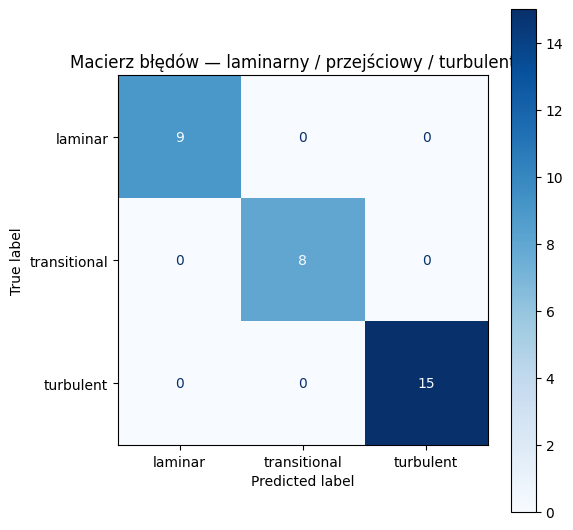

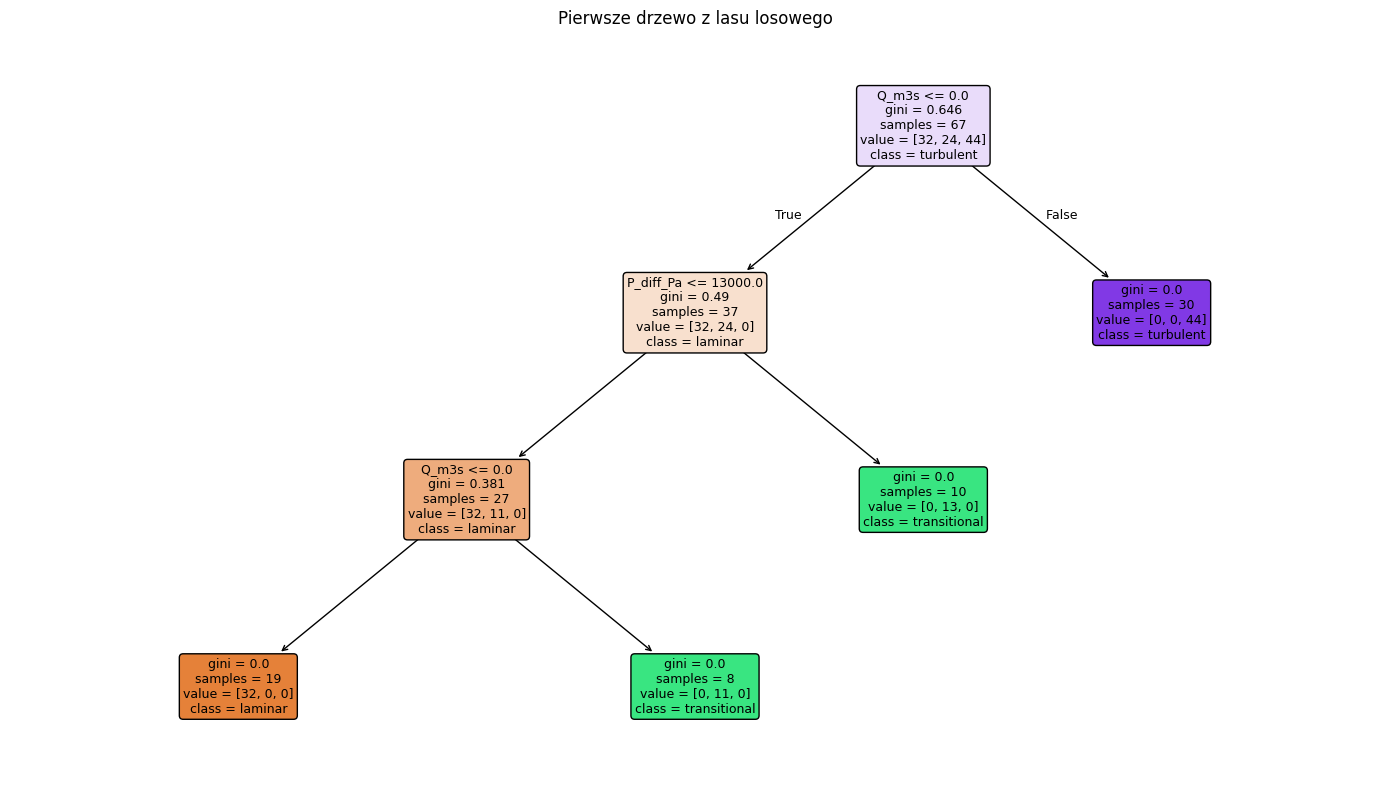

Ważność cech:
  P_diff_Pa: 0.1115
  Q_m3s: 0.5965



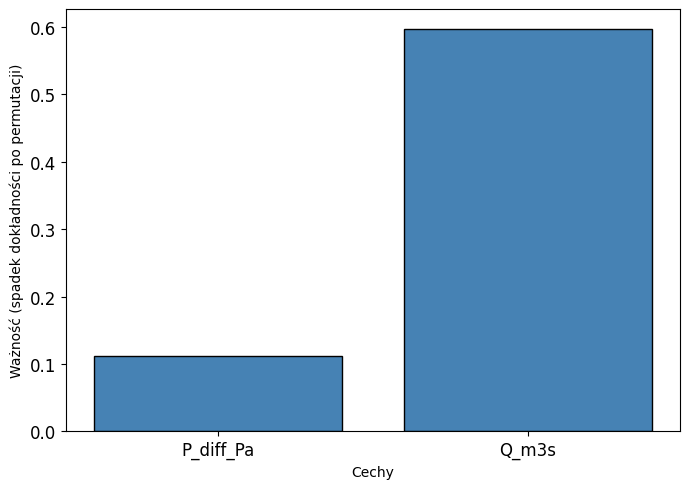

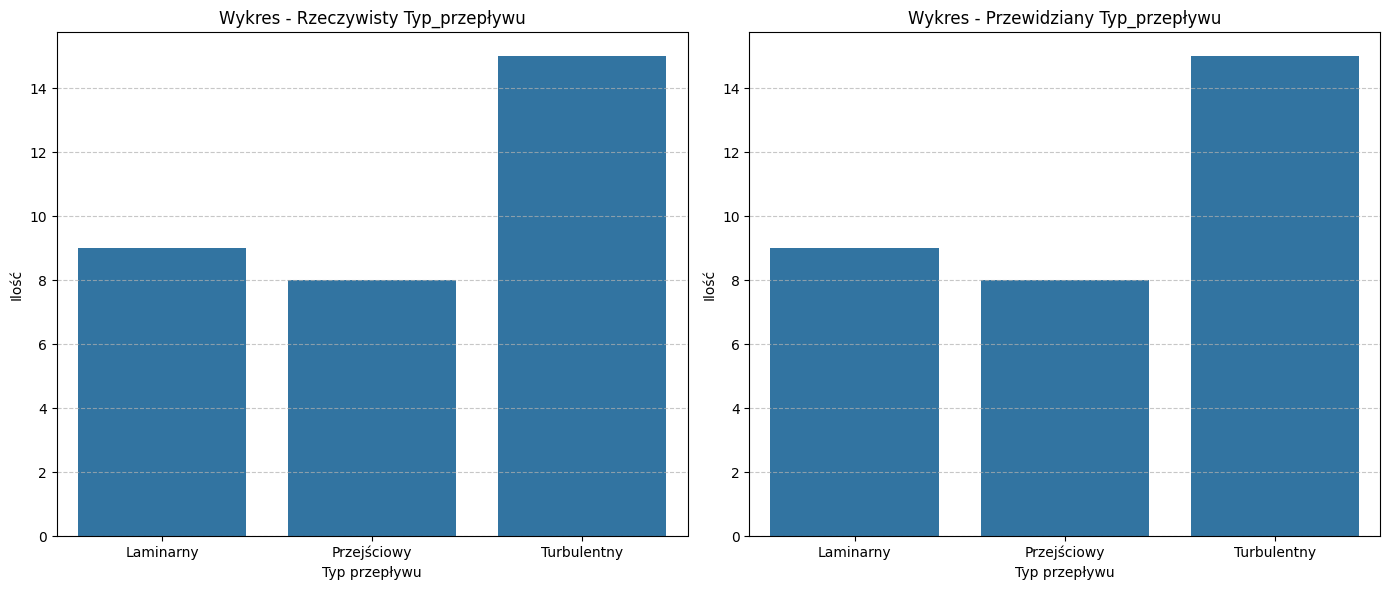

Rzeczywisty:
Typ_przepływu
Turbulentny    15
Laminarny       9
Przejściowy     8
Name: count, dtype: int64

Przewidziany:
Typ_przepływu
Turbulentny    15
Laminarny       9
Przejściowy     8
Name: count, dtype: int64



In [127]:
# Macierz błędów (Confusion Matrix) — odpowiednik confusionmat w MATLAB-ie

labels_order = ["laminar", "transitional", "turbulent"]
conf_mat = confusion_matrix(y_test, predicted_labels, labels=labels_order)

fig1, ax1 = plt.subplots(figsize=(6, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=labels_order)
disp.plot(ax=ax1, cmap="Blues", colorbar=True, values_format="d")
ax1.set_title("Macierz błędów — laminarny / przejściowy / turbulentny")
plt.tight_layout()
plt.show()


# Wizualizacja pierwszego drzewa z lasu losowego

fig2, ax2 = plt.subplots(figsize=(14, 8))
plot_tree(
    rf_model.estimators_[0],
    feature_names=["P_diff_Pa", "Q_m3s"],
    class_names=rf_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax2,
)
ax2.set_title("Pierwsze drzewo z lasu losowego")
plt.tight_layout()
plt.show()


# Ważność cech (Feature Importance) — odpowiednik OOBPermutedVarDeltaError w MATLAB-ie
# OOBPermutedVarDeltaError w MATLAB-ie mierzy, jak bardzo wzrasta błąd
# predykcji Out-Of-Bag po losowej permutacji wartości danej cechy.
# permutation_importance() w scikit-learn realizuje tę samą ideę: permutuje
# po kolei każdą cechę i mierzy spadek jakości modelu (tutaj: accuracy).
# Działa identycznie dla klasyfikacji wieloklasowej.

perm_result = permutation_importance(
    rf_model, X_train, y_train,
    n_repeats=30,         # liczba powtórzeń permutacji dla stabilności wyniku
    random_state=42,
    scoring="accuracy",
)
feature_importance = perm_result.importances_mean
feature_names = ["P_diff_Pa", "Q_m3s"]

print("Ważność cech:")
for name, imp in zip(feature_names, feature_importance):
    print(f"  {name}: {imp:.4f}")
print()

fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.bar(feature_names, feature_importance, color="steelblue", edgecolor="black")
ax3.set_xlabel("Cechy")
ax3.set_ylabel("Ważność (spadek dokładności po permutacji)")
ax3.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()


# Porównanie rozkładu klas rzeczywistych i przewidzianych (laminar / transitional / turbulent)

flow_type_labels_pl = {
    "laminar": "Laminarny",
    "transitional": "Przejściowy",
    "turbulent": "Turbulentny",
}

y_true_labels = pd.Series(y_test, name="Typ_przepływu").map(flow_type_labels_pl)
y_pred_labels = pd.Series(predicted_labels, name="Typ_przepływu").map(flow_type_labels_pl)

# Ustalona kolejność kategorii na osi X (żeby obie strony wykresu były porównywalne)
order_pl = ["Laminarny", "Przejściowy", "Turbulentny"]

fig4, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x=y_true_labels, order=order_pl, ax=axes[0])
axes[0].set_title("Wykres - Rzeczywisty Typ_przepływu")
axes[0].set_xlabel("Typ przepływu")
axes[0].set_ylabel("Ilość")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

sns.countplot(x=y_pred_labels, order=order_pl, ax=axes[1])
axes[1].set_title("Wykres - Przewidziany Typ_przepływu")
axes[1].set_xlabel("Typ przepływu")
axes[1].set_ylabel("Ilość")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

print("Rzeczywisty:")
print(y_true_labels.value_counts())

print("\nPrzewidziany:")
print(y_pred_labels.value_counts())
print()